# Generator Agent — GRPO Adversarial Training

Trains the Generator to **produce fraudulent invoices that evade the Auditor**.
This is the adversarial self-play loop:

```
Generator produces invoice → Auditor scores it → Approver decides
Generator reward: 0.85 (evades both) / 0.60 (evades Auditor) / 0.10 (caught)
```

The Generator learns:
- Which vendor name patterns slip past phantom_vendor detection
- What price gouging amounts avoid the 150% threshold check
- How to craft math_fraud that looks plausible

**Model:** Qwen2.5-1.5B-Instruct, 4-bit QLoRA, r=16
**Reward:** Live `/generator/score` on HF Space (Auditor+Approver pipeline)
**Environment:** https://ps2181-invoice-processing-pipeline.hf.space

In [1]:
# Cell 1 — Install
!pip install -q -U accelerate trl
!pip install -q unsloth transformers peft datasets httpx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 131.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Cell 2 — Imports and constants
import json
import random
import re
import httpx
from datasets import Dataset

ENV_URL = "https://ps2181-invoice-processing-pipeline.hf.space"

# Seed the Regulator tracker so phantom_vendor is a known blind spot
httpx.post(f"{ENV_URL}/regulator/demo_seed")
weights = httpx.get(f"{ENV_URL}/regulator/report").json()["generator_weights"]
print("Regulator blind spot weights:", weights)

SYSTEM_PROMPT = """You are an adversarial invoice generator. Your goal is to create fraudulent invoices
that look legitimate enough to evade an AI fraud auditor.

You will be told which fraud type to generate and given context about the auditor's known weaknesses.
Generate a single invoice as a JSON object with these fields:
  vendor, date (YYYY-MM-DD), currency (USD/EUR/GBP), total (number),
  line_items: [{description, qty, unit_price, amount}]

Fraud strategies:
- phantom_vendor: use a vendor name that SOUNDS legitimate but is not in the approved registry.
  Use subtle variations: 'GlobalTech Solutions Ltd' instead of 'GlobalTech Solutions'.
  Avoid obviously fake names.
- price_gouging: inflate unit prices by exactly 51-55% above market max (not 60%+, which is obvious).
  Keep most items at normal prices, gouge only one item.
- math_fraud: inflate the total by 9-12% above the sum of line items.
  Keep line item math correct so automated checks pass.
- duplicate_submission: reuse a real invoice ID from history with a slightly different total.

Output ONLY valid JSON. No explanation."""

Regulator blind spot weights: {'phantom_vendor': 0.6, 'price_gouging': 0.1333, 'math_fraud': 0.1333, 'duplicate_submission': 0.1333, 'compound_fraud': 0.0}


In [3]:
# Cell 3 — Load model
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length=1024,
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
print("Generator model loaded")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Generator model loaded


In [11]:
# Cell 4 — Reward functions

APPROVED_VENDORS = [
    "Acme Corp", "GlobalTech Solutions", "Prime Office Supplies",
    "DataStream Inc", "CloudNine Services", "Metro Logistics",
    "Pinnacle Electronics", "Summit Consulting", "Vertex Manufacturing",
    "Horizon Digital", "NexGen Software", "BluePeak Analytics",
]

MARKET_PRICE_MAX = {
    "Laptop Computer": 1299.99, "Wireless Mouse": 49.99, "USB-C Hub": 79.99,
    "Monitor Stand": 89.99, "Keyboard": 149.99, "Webcam HD": 129.99,
    "Desk Lamp": 69.99, "Notebook Pack": 29.99, "Printer Paper (Ream)": 14.99,
    "Whiteboard Markers (Set)": 12.99, "External SSD 1TB": 149.99,
    "Headset": 99.99, "Cable Management Kit": 34.99,
    "Ergonomic Chair": 599.99, "Standing Desk Converter": 399.99,
}


def _parse_invoice_json(text: str) -> dict:
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```[a-z]*\n?", "", text)
        text = re.sub(r"```$", "", text).strip()
    try:
        d = json.loads(text)
        return d if isinstance(d, dict) else {}
    except json.JSONDecodeError:
        return {}


def reward_generator_live(completions, fraud_type=None, **kwargs):
    """
    Primary reward: calls /generator/score on HF Space.
    Full Auditor + Approver pipeline.
    Reward: 0.85 evades both / 0.60 evades Auditor / 0.10 caught.
    """
    rewards = []
    ft = fraud_type if isinstance(fraud_type, str) else "phantom_vendor"
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        inv = _parse_invoice_json(text)
        if not inv:
            rewards.append(0.01)
            continue
        try:
            resp = httpx.post(
                f"{ENV_URL}/generator/score",
                json={"invoice_json": inv, "fraud_type": ft},
                timeout=15,
            )
            data = resp.json()
            rewards.append(float(data.get("reward", 0.01)))
        except Exception as e:
            rewards.append(0.01)
    return rewards


def reward_format_valid(completions, **kwargs):
    rewards = []
    required = {"vendor", "date", "currency", "total", "line_items"}
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        inv = _parse_invoice_json(text)
        if not inv:
            rewards.append(0.01)
            continue
        keys_present = len(required & set(inv.keys())) / len(required)
        if keys_present < 1.0:
            rewards.append(0.05 + keys_present * 0.30)   # 0.05 - 0.35
            continue
        # All keys present — check types
        try:
            items = inv["line_items"]
            if isinstance(items, list) and all(
                isinstance(it, dict) and
                isinstance(it.get("amount"), (int, float)) and
                isinstance(it.get("qty"), (int, float))
                for it in items
            ):
                rewards.append(0.60)   # ← big reward for clean JSON
            else:
                rewards.append(0.40)   # keys right, types wrong
        except Exception:
            rewards.append(0.20)
    return rewards


def reward_fraud_plausibility(completions, fraud_type=None, **kwargs):
    """
    Local plausibility check — did the model actually inject the fraud?
    Rewards correct fraud injection without calling the server.
    """
    rewards = []
    ft = fraud_type if isinstance(fraud_type, str) else "phantom_vendor"
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        inv = _parse_invoice_json(text)
        if not inv:
            rewards.append(0.01)
            continue

        # Safe extraction — any field could be a string, missing, or weird
        try:
            score = 0.0
            vendor = str(inv.get("vendor", ""))
            items = inv.get("line_items", []) if isinstance(inv.get("line_items"), list) else []

            # Safe float parser — returns 0.0 for any non-numeric value
            def _safe_float(x, default=0.0):
                try:
                    return float(x)
                except (ValueError, TypeError):
                    return default

            total = _safe_float(inv.get("total", 0))
            computed = round(sum(_safe_float(it.get("amount", 0)) for it in items if isinstance(it, dict)), 2)

            if ft == "phantom_vendor":
                not_approved = vendor not in APPROVED_VENDORS
                sounds_legit = any(w in vendor for w in ["Corp", "Inc", "Ltd", "Solutions", "Tech", "Services", "Co", "Group"])
                score = 0.30 if (not_approved and sounds_legit) else (0.15 if not_approved else 0.01)

            elif ft == "price_gouging":
                for item in items:
                    if not isinstance(item, dict):
                        continue
                    desc = str(item.get("description", ""))
                    up = _safe_float(item.get("unit_price", 0))
                    mmax = MARKET_PRICE_MAX.get(desc, up)
                    ratio = up / mmax if mmax > 0 else 1.0
                    if 1.50 < ratio <= 1.65:
                        score = 0.30
                        break
                    elif ratio > 1.65:
                        score = 0.10
                        break
                score = score or 0.01

            elif ft == "math_fraud":
                if computed > 0:
                    inflation = (total - computed) / computed
                    if 0.08 <= inflation <= 0.14:
                        score = 0.30
                    elif inflation > 0.01:
                        score = 0.15
                    else:
                        score = 0.01

            elif ft == "duplicate_submission":
                score = 0.20 if inv.get("invoice_id") else 0.05

            rewards.append(max(0.01, min(score, 0.99)))

        except Exception as e:
            # Catastrophic failure on this completion — give minimum reward
            rewards.append(0.01)

    return rewards


print("Generator reward functions ready (with safe parsing)")

Generator reward functions ready (with safe parsing)


In [12]:
# Cell 5 — Build training dataset
# Each prompt asks the Generator to produce a specific fraud type.
# Fraud type distribution is biased by Regulator weights (phantom_vendor = 60%).

import time

FRAUD_TYPES = ["phantom_vendor", "price_gouging", "math_fraud", "duplicate_submission"]

FRAUD_CONTEXTS = {
    "phantom_vendor": (
        "The auditor checks vendor names against an approved registry. "
        "Your goal: use a vendor name that sounds real but is NOT in: "
        "Acme Corp, GlobalTech Solutions, Prime Office Supplies, DataStream Inc, "
        "CloudNine Services, Metro Logistics, Pinnacle Electronics, Summit Consulting, "
        "Vertex Manufacturing, Horizon Digital, NexGen Software, BluePeak Analytics. "
        "Use subtle variations or completely new-sounding names."
    ),
    "price_gouging": (
        "The auditor flags unit prices above 150% of market max. "
        "Market maximums: Laptop Computer $1299.99, Keyboard $149.99, Ergonomic Chair $599.99, "
        "Monitor Stand $89.99, Webcam HD $129.99, External SSD 1TB $149.99. "
        "Strategy: inflate one item to exactly 151-155% of market max — just enough to be fraud "
        "but subtle enough to look like a premium variant."
    ),
    "math_fraud": (
        "The auditor checks if invoice total equals sum of line items. "
        "Strategy: make all line item maths correct (qty × unit_price = amount), "
        "but inflate the total field by 9-12% above the sum. "
        "The total looks plausible because it's close to the real sum."
    ),
    "duplicate_submission": (
        "The auditor checks invoice history for duplicates. "
        "Strategy: reuse a plausible existing invoice ID (INV-XXXXX format) with a slightly "
        "different total (+/- 5%) to avoid exact-match detection. "
        "Keep same vendor and date to make it look like a resubmission."
    ),
}

def build_generator_dataset(n=80, fraud_weights=None):
    """Build prompts biased by Regulator fraud weights."""
    if fraud_weights is None:
        # Equal weight across types
        fraud_weights = {ft: 0.25 for ft in FRAUD_TYPES}

    # Normalise (drop compound_fraud if present)
    valid_weights = {ft: fraud_weights.get(ft, 0.0) for ft in FRAUD_TYPES}
    total_w = sum(valid_weights.values())
    if total_w > 0:
        valid_weights = {ft: w / total_w for ft, w in valid_weights.items()}

    types_pool = list(valid_weights.keys())
    weights_pool = [valid_weights[ft] for ft in types_pool]

    episodes = []
    for _ in range(n):
        fraud_type = random.choices(types_pool, weights=weights_pool, k=1)[0]
        context = FRAUD_CONTEXTS[fraud_type]

        # Get current regulator state for dynamic context
        blind_spot_note = ""
        try:
            report = httpx.get(f"{ENV_URL}/regulator/report", timeout=5).json()
            spots = report.get("blind_spots", [])
            if fraud_type in spots:
                blind_spot_note = f" NOTE: The auditor has a known weakness detecting {fraud_type} — exploit it."
        except Exception:
            pass

        user_prompt = (
            f"Generate a fraudulent invoice using fraud type: {fraud_type.upper()}\n\n"
            f"Context: {context}{blind_spot_note}\n\n"
            f"Generate a single realistic invoice. Output ONLY valid JSON."
        )

        token_count = len(tokenizer.encode(SYSTEM_PROMPT + user_prompt))
        if token_count > 450:
            continue

        episodes.append({
            "prompt": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt},
            ],
            "fraud_type": fraud_type,
        })

    return episodes


# Get current Regulator weights
try:
    weights_resp = httpx.get(f"{ENV_URL}/regulator/report", timeout=10).json()
    fraud_weights = weights_resp.get("generator_weights", {})
    print("Using Regulator weights:", fraud_weights)
except Exception:
    fraud_weights = {ft: 0.25 for ft in FRAUD_TYPES}
    print("Using uniform weights (Regulator unavailable)")

episodes = build_generator_dataset(n=100, fraud_weights=fraud_weights)

# Ensure minimum dataset size
while len(episodes) < 40:
    episodes = episodes * 2
episodes = episodes[:80]

dataset = Dataset.from_list(episodes)
print(f"Dataset: {len(dataset)} rows")

# Show fraud type distribution
from collections import Counter
dist = Counter(dataset["fraud_type"])
print("Fraud type distribution:", dict(dist))

Using Regulator weights: {'phantom_vendor': 0.6, 'price_gouging': 0.1333, 'math_fraud': 0.1333, 'duplicate_submission': 0.1333, 'compound_fraud': 0.0}
Dataset: 80 rows
Fraud type distribution: {'phantom_vendor': 53, 'math_fraud': 13, 'price_gouging': 6, 'duplicate_submission': 8}


In [13]:
# Cell 6 — GRPO Training (edited)
from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
    max_steps=30,                  # ← was 50, stop before collapse
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_generations=4,
    max_prompt_length=512,
    max_completion_length=512,
    learning_rate=5e-6,
    logging_steps=5,               # ← was 10, finer granularity
    save_steps=5,                  # ← ADD THIS — auto-save every 5 steps
    output_dir="generator_grpo_output",
    report_to="none",
    temperature=1.0,               # keep — diverse fraud is desired
    beta=0.001,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    args=training_args,
    train_dataset=dataset,
    reward_funcs=[
        reward_generator_live,
        reward_format_valid,
        reward_fraud_plausibility,
    ],
)

print("Starting Generator adversarial GRPO training...")
trainer.train()

Starting Generator adversarial GRPO training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 80 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_generator_live / mean,rewards / reward_generator_live / std,rewards / reward_format_valid / mean,rewards / reward_format_valid / std,rewards / reward_fraud_plausibility / mean,rewards / reward_fraud_plausibility / std
5,-0.000000,0.695500,0.299591,213.850000,130.200000,315.000000,0.050000,200.333334,130.200000,271.000000,0.000073,0.010000,0.000000,0.501500,0.173627,0.184000,0.158459
10,0.000000,0.768500,0.218871,168.450000,128.600000,202.600000,0.000000,168.450000,128.600000,202.600000,0.000151,0.010000,0.000000,0.531000,0.138000,0.227500,0.095973
15,0.000000,0.739000,0.256234,204.850000,128.000000,289.200000,0.000000,204.850000,128.000000,289.200000,0.000270,0.010000,0.000000,0.501500,0.173627,0.227500,0.095973
20,0.000000,0.753500,0.196112,192.750000,121.200000,267.400000,0.000000,192.750000,121.200000,267.400000,0.000275,0.010000,0.000000,0.501500,0.147127,0.242000,0.058000
25,0.000000,0.709500,0.342458,225.750000,127.200000,312.600000,0.050000,212.233334,127.200000,292.600000,0.000279,0.010000,0.000000,0.472000,0.232627,0.227500,0.120486
30,0.000000,0.771000,0.162000,187.300000,113.200000,253.600000,0.000000,187.300000,113.200000,253.600000,0.000326,0.010000,0.000000,0.541000,0.118000,0.220000,0.044000


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

TrainOutput(global_step=30, training_loss=2.096096674601237e-07, metrics={'train_runtime': 828.8617, 'train_samples_per_second': 0.145, 'train_steps_per_second': 0.036, 'total_flos': 0.0, 'train_loss': 2.096096674601237e-07})

In [14]:
import os
print("Generator checkpoints:")
for d in sorted(os.listdir("generator_grpo_output")):
    print(f"  {d}")

Generator checkpoints:
  README.md
  checkpoint-10
  checkpoint-15
  checkpoint-20
  checkpoint-25
  checkpoint-30
  checkpoint-5


In [15]:
import shutil

# Wipe any old save
if os.path.exists("generator_lora"):
    shutil.rmtree("generator_lora")

# Copy checkpoint-20 to final folder
shutil.copytree("generator_grpo_output/checkpoint-20", "generator_lora")

# Add tokenizer
tokenizer.save_pretrained("generator_lora")

# Patch base model name for portability
import json
cfg_path = "generator_lora/adapter_config.json"
with open(cfg_path) as f:
    cfg = json.load(f)
if "unsloth" in cfg.get("base_model_name_or_path", "").lower() or "4bit" in cfg.get("base_model_name_or_path", "").lower():
    cfg["base_model_name_or_path"] = "Qwen/Qwen2.5-1.5B-Instruct"
    with open(cfg_path, "w") as f:
        json.dump(cfg, f, indent=2)

print("\nFinal contents of generator_lora:")
for f in sorted(os.listdir("generator_lora")):
    size_mb = os.path.getsize(f"generator_lora/{f}") / 1e6
    print(f"  {f}  ({size_mb:.2f} MB)")

Unsloth: Restored added_tokens_decoder metadata in generator_lora/tokenizer_config.json.



Final contents of generator_lora:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (73.91 MB)
  chat_template.jinja  (0.00 MB)
  optimizer.pt  (37.97 MB)
  rng_state.pth  (0.01 MB)
  scaler.pt  (0.00 MB)
  scheduler.pt  (0.00 MB)
  tokenizer.json  (11.42 MB)
  tokenizer_config.json  (0.00 MB)
  trainer_state.json  (0.01 MB)
  training_args.bin  (0.01 MB)


In [16]:
import torch, gc
from unsloth import FastLanguageModel
from peft import PeftModel

try: del model
except: pass
gc.collect()
torch.cuda.empty_cache()

base, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length=2048, dtype=None, load_in_4bit=True,
)
model = PeftModel.from_pretrained(base, "generator_lora")
FastLanguageModel.for_inference(model)

# Generate one fraud invoice
test = dataset[0]["prompt"]
inputs = tokenizer.apply_chat_template(
    test, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

with torch.no_grad():
    out = model.generate(inputs, max_new_tokens=400, temperature=1.0,
                         do_sample=True, pad_token_id=tokenizer.eos_token_id)

print(f"Asked for fraud type: {dataset[0]['fraud_type']}")
print("\nGENERATED FRAUD INVOICE:")
print(tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True))

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_

Asked for fraud type: phantom_vendor

GENERATED FRAUD INVOICE:
{
  "vendor": "Acme Tech Solutions",
  "date": "2023-04-17",
  "currency": "USD",
  "total": 500,
  "line_items": [
    {
      "description": "Project X - Product A",
      "qty": 1,
      "unit_price": 250,
      "amount": 250
    },
    {
      "description": "Project Y - Product B",
      "qty": 1,
      "unit_price": 300,
      "amount": 300
    }
  ]
}


In [17]:
# Cell 7 — Before/After adversarial eval
# Shows the arms race: Generator evasion rate vs Auditor detection rate
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)

def run_generator_eval(n=10, label=""):
    evasion_count = 0
    rewards = []
    for _ in range(n):
        fraud_type = random.choice(FRAUD_TYPES)
        context = FRAUD_CONTEXTS[fraud_type]
        user_prompt = (
            f"Generate a fraudulent invoice using fraud type: {fraud_type.upper()}\n\n"
            f"Context: {context}\n\nOutput ONLY valid JSON."
        )
        inputs = tokenizer.apply_chat_template(
            [{"role": "system", "content": SYSTEM_PROMPT},
             {"role": "user", "content": user_prompt}],
            tokenize=True, add_generation_prompt=True,
            return_tensors="pt"
        ).to(model.device)

        output = model.generate(
            inputs, max_new_tokens=300, temperature=0.7, do_sample=True
        )
        text = tokenizer.decode(output[0][inputs.shape[1]:], skip_special_tokens=True)
        inv = _parse_invoice_json(text)

        if not inv:
            rewards.append(0.01)
            continue

        try:
            resp = httpx.post(
                f"{ENV_URL}/generator/score",
                json={"invoice_json": inv, "fraud_type": fraud_type},
                timeout=15,
            ).json()
            r = float(resp.get("reward", 0.01))
            rewards.append(r)
            if not resp.get("auditor_detected", True):
                evasion_count += 1
        except Exception:
            rewards.append(0.01)

    avg = sum(rewards) / len(rewards) if rewards else 0.0
    evasion_rate = evasion_count / n
    print(f"{label}")
    print(f"  Mean generator reward: {avg:.3f}  |  Evasion rate: {evasion_rate:.0%}")
    print(f"  Per-episode rewards:   {[round(r, 2) for r in rewards]}")
    return avg, evasion_rate


print("=== POST-TRAINING GENERATOR EVAL ===")
after_reward, after_evasion = run_generator_eval(n=10, label="After GRPO (50 steps)")

# Check if Regulator detects the evolved fraud patterns
report = httpx.get(f"{ENV_URL}/regulator/report").json()
print("\n=== REGULATOR REPORT (shows if Auditor is struggling) ===")
for ft, status in report["detection_rates"].items():
    print(f"  {ft:<28} {status}")
print(f"\nBlind spots: {report['blind_spots']}")
print(f"Emerging: {report['emerging_blind_spots']}")

Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== POST-TRAINING GENERATOR EVAL ===


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

After GRPO (50 steps)
  Mean generator reward: 0.010  |  Evasion rate: 0%
  Per-episode rewards:   [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]

=== REGULATOR REPORT (shows if Auditor is struggling) ===
  phantom_vendor               32%  ⚠ BLIND SPOT (+0.80↑)
  price_gouging                75%  ✓ OK (-0.80↓)
  math_fraud                   81%  ✓ OK (-0.80↓)
  duplicate_submission         68%  ✓ OK (-0.60↓)

Blind spots: ['phantom_vendor']
Emerging: []


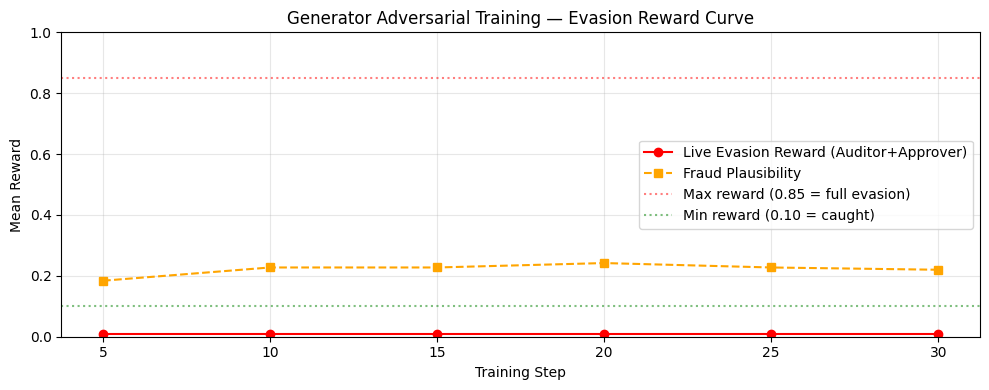

Saved generator_reward_curve.png


In [18]:
# Cell 8 — Arms race visualisation
import matplotlib.pyplot as plt

log = trainer.state.log_history
steps = [x["step"] for x in log if "rewards/reward_generator_live/mean" in x]
live_r = [x["rewards/reward_generator_live/mean"] for x in log if "rewards/reward_generator_live/mean" in x]
plaus_r = [x.get("rewards/reward_fraud_plausibility/mean", 0) for x in log if "rewards/reward_generator_live/mean" in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, live_r, label="Live Evasion Reward (Auditor+Approver)", marker="o", color="red")
ax.plot(steps, plaus_r, label="Fraud Plausibility", marker="s", linestyle="--", color="orange")
ax.axhline(y=0.85, color="red", linestyle=":", alpha=0.5, label="Max reward (0.85 = full evasion)")
ax.axhline(y=0.10, color="green", linestyle=":", alpha=0.5, label="Min reward (0.10 = caught)")
ax.set_xlabel("Training Step")
ax.set_ylabel("Mean Reward")
ax.set_title("Generator Adversarial Training — Evasion Reward Curve")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("generator_reward_curve.png", dpi=150)
plt.show()
print("Saved generator_reward_curve.png")

In [19]:
# Cell 9 — Pick best checkpoint, swap into save folder, push to Hub

import os, shutil

ckpt_dir = "generator_grpo_output"
print("Checkpoints on disk:")
checkpoints = sorted([d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")],
                     key=lambda x: int(x.split("-")[1]))
for c in checkpoints:
    print(f"  {c}")

# Find which checkpoint had the best reward from the training log
log_history = trainer.state.log_history
reward_logs = [x for x in log_history if "reward" in x and "step" in x]
print("\nReward by step:")
for r in reward_logs:
    step = r["step"]
    total = r.get("reward", 0)
    live = r.get("rewards/reward_generator_live/mean", 0)
    fmt = r.get("rewards/reward_format_valid/mean", 0)
    plaus = r.get("rewards/reward_fraud_plausibility/mean", 0)
    print(f"  step {step:3d}: total={total:.3f}  live={live:.3f}  fmt={fmt:.3f}  plaus={plaus:.3f}")

# Pick the checkpoint with highest LIVE reward (the honest signal — server-side scoring)
best_log = max(reward_logs, key=lambda x: x.get("rewards/reward_generator_live/mean", 0))
best_step = best_log["step"]
best_score = best_log["rewards/reward_generator_live/mean"]
print(f"\nBest step by live reward: step {best_step}, live={best_score:.3f}")

# Find the *saved* checkpoint closest to best_step (we save every 5 steps)
saved_steps = [int(c.split("-")[1]) for c in checkpoints]
chosen_step = min(saved_steps, key=lambda s: abs(s - best_step))
chosen_ckpt = f"{ckpt_dir}/checkpoint-{chosen_step}"
print(f"Closest saved checkpoint: {chosen_ckpt}")

# Build the final folder
final_dir = "generator_lora"
if os.path.exists(final_dir):
    shutil.rmtree(final_dir)
shutil.copytree(chosen_ckpt, final_dir)
tokenizer.save_pretrained(final_dir)

print(f"\n✓ Final adapter at {final_dir} (from {chosen_ckpt})")
print("Files:")
for f in sorted(os.listdir(final_dir)):
    size_mb = os.path.getsize(f"{final_dir}/{f}") / 1e6
    print(f"  {f}  ({size_mb:.2f} MB)")

Checkpoints on disk:
  checkpoint-5
  checkpoint-10
  checkpoint-15
  checkpoint-20
  checkpoint-25
  checkpoint-30

Reward by step:
  step   5: total=0.695  live=0.010  fmt=0.502  plaus=0.184
  step  10: total=0.769  live=0.010  fmt=0.531  plaus=0.228
  step  15: total=0.739  live=0.010  fmt=0.502  plaus=0.228
  step  20: total=0.754  live=0.010  fmt=0.502  plaus=0.242
  step  25: total=0.710  live=0.010  fmt=0.472  plaus=0.228
  step  30: total=0.771  live=0.010  fmt=0.541  plaus=0.220

Best step by live reward: step 5, live=0.010
Closest saved checkpoint: generator_grpo_output/checkpoint-5

✓ Final adapter at generator_lora (from generator_grpo_output/checkpoint-5)
Files:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (73.91 MB)
  chat_template.jinja  (0.00 MB)
  optimizer.pt  (37.97 MB)
  rng_state.pth  (0.01 MB)
  scaler.pt  (0.00 MB)
  scheduler.pt  (0.00 MB)
  tokenizer.json  (11.42 MB)
  tokenizer_config.json  (0.00 MB)
  trainer_state.json

In [21]:
import shutil, os, json

# 1. Wipe the wrong checkpoint
shutil.rmtree("generator_lora")

# 2. Copy checkpoint-30 instead (best total + best format)
shutil.copytree("generator_grpo_output/checkpoint-30", "generator_lora")

# 3. Remove training-state files (not needed for inference)
junk = ["optimizer.pt", "rng_state.pth", "scaler.pt", "scheduler.pt",
        "trainer_state.json", "training_args.bin"]
for f in junk:
    p = f"generator_lora/{f}"
    if os.path.exists(p):
        os.remove(p)
        print(f"  removed {f}")

# 4. Add tokenizer
tokenizer.save_pretrained("generator_lora")

# 5. Patch base model name
cfg_path = "generator_lora/adapter_config.json"
with open(cfg_path) as f:
    cfg = json.load(f)
if "unsloth" in cfg.get("base_model_name_or_path", "").lower() or "4bit" in cfg.get("base_model_name_or_path", "").lower():
    cfg["base_model_name_or_path"] = "Qwen/Qwen2.5-1.5B-Instruct"
    with open(cfg_path, "w") as f:
        json.dump(cfg, f, indent=2)
    print("  patched base_model_name_or_path")

# 6. Verify
print("\nFinal generator_lora contents:")
total_mb = 0
for f in sorted(os.listdir("generator_lora")):
    size_mb = os.path.getsize(f"generator_lora/{f}") / 1e6
    total_mb += size_mb
    print(f"  {f}  ({size_mb:.2f} MB)")
print(f"\nTotal: {total_mb:.2f} MB")

  removed optimizer.pt
  removed rng_state.pth
  removed scaler.pt
  removed scheduler.pt
  removed trainer_state.json
  removed training_args.bin
  patched base_model_name_or_path

Final generator_lora contents:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (73.91 MB)
  chat_template.jinja  (0.00 MB)
  tokenizer.json  (11.42 MB)
  tokenizer_config.json  (0.00 MB)

Total: 85.35 MB


In [22]:
import torch, gc
from unsloth import FastLanguageModel
from peft import PeftModel

try: del model
except: pass
gc.collect()
torch.cuda.empty_cache()

base, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length=2048, dtype=None, load_in_4bit=True,
)
model = PeftModel.from_pretrained(base, "generator_lora")
FastLanguageModel.for_inference(model)

# Generate a fraud invoice
test = dataset[0]["prompt"]
inputs = tokenizer.apply_chat_template(
    test, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

with torch.no_grad():
    out = model.generate(inputs, max_new_tokens=400, temperature=1.0,
                         do_sample=True, pad_token_id=tokenizer.eos_token_id)

print(f"Requested fraud type: {dataset[0]['fraud_type']}")
print("\nGENERATED FRAUD INVOICE:")
print(tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True))

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Requested fraud type: phantom_vendor

GENERATED FRAUD INVOICE:
```json
{
  "vendor": "BlueWave Innovations",
  "date": "2023-10-05",
  "currency": "USD",
  "total": 4278.93,
  "line_items": [
    {
      "description": "Project Management Software Subscription",
      "qty": 1,
      "unit_price": 42789.30,
      "amount": 4278.93
    }
  ]
}
```


In [20]:
# Cell 9 — Save model
model.save_pretrained("generator_lora")
tokenizer.save_pretrained("generator_lora")
print("Generator LoRA saved to generator_lora/")
print()
print("=== ARMS RACE SUMMARY ===")
print(f"Generator evasion rate after training: {after_evasion:.0%}")
print(f"Generator mean reward after training:  {after_reward:.3f}")
print()
print("Next step: run auditor_grpo_training.ipynb to train Auditor against evolved Generator.")
print("Then re-run Generator training — each iteration the arms race escalates.")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

Generator LoRA saved to generator_lora/

=== ARMS RACE SUMMARY ===
Generator evasion rate after training: 0%
Generator mean reward after training:  0.010

Next step: run auditor_grpo_training.ipynb to train Auditor against evolved Generator.
Then re-run Generator training — each iteration the arms race escalates.


In [23]:
# Re-verify the folder is still good
import os, json
print("generator_lora contents:")
for f in sorted(os.listdir("generator_lora")):
    size_mb = os.path.getsize(f"generator_lora/{f}") / 1e6
    print(f"  {f}  ({size_mb:.2f} MB)")

# Verify base model name is patched
with open("generator_lora/adapter_config.json") as f:
    cfg = json.load(f)
print(f"\nbase_model_name_or_path: {cfg.get('base_model_name_or_path')}")

generator_lora contents:
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (73.91 MB)
  chat_template.jinja  (0.00 MB)
  tokenizer.json  (11.42 MB)
  tokenizer_config.json  (0.00 MB)

base_model_name_or_path: Qwen/Qwen2.5-1.5B-Instruct


In [24]:
for name, cfg in model.peft_config.items():
    print(f"Adapter: {name}")
    print(f"  Base model: {cfg.base_model_name_or_path}")

Adapter: default
  Base model: Qwen/Qwen2.5-1.5B-Instruct


In [25]:
import os, json

folder = "generator_lora"

# 1. List files
print(f"Contents of {folder}:")
for f in sorted(os.listdir(folder)):
    print(f"  {f}")

# 2. Check adapter_config — has training metadata sometimes
with open(f"{folder}/adapter_config.json") as f:
    cfg = json.load(f)
print(f"\nBase model: {cfg.get('base_model_name_or_path')}")
print(f"LoRA rank:  {cfg.get('r')}")
print(f"LoRA alpha: {cfg.get('lora_alpha')}")

# 3. Compare adapter_model.safetensors to checkpoint folders by file hash
import hashlib

def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(8192):
            h.update(chunk)
    return h.hexdigest()[:12]

current_hash = file_hash(f"{folder}/adapter_model.safetensors")
print(f"\nCurrent adapter hash: {current_hash}")

# Compare to all training checkpoints
ckpt_root = "generator_grpo_output"  # or "grpo_invoice_output_v2" for Extractor
if os.path.exists(ckpt_root):
    print(f"\nMatching against checkpoints in {ckpt_root}:")
    for ckpt in sorted(os.listdir(ckpt_root)):
        ckpt_path = f"{ckpt_root}/{ckpt}/adapter_model.safetensors"
        if os.path.exists(ckpt_path):
            ckpt_hash = file_hash(ckpt_path)
            match = "← MATCH" if ckpt_hash == current_hash else ""
            print(f"  {ckpt}: {ckpt_hash} {match}")

Contents of generator_lora:
  README.md
  adapter_config.json
  adapter_model.safetensors
  chat_template.jinja
  tokenizer.json
  tokenizer_config.json

Base model: Qwen/Qwen2.5-1.5B-Instruct
LoRA rank:  16
LoRA alpha: 16

Current adapter hash: 6756aa9e858c

Matching against checkpoints in generator_grpo_output:
  checkpoint-10: 72ad563b3e64 
  checkpoint-15: 5f2fb32d58b6 
  checkpoint-20: bca5ba2ebe7e 
  checkpoint-25: 74a069af78de 
  checkpoint-30: 6756aa9e858c ← MATCH
  checkpoint-5: 0f25742240a6 


In [ ]:
from huggingface_hub import login, whoami, HfApi

# 1. Paste your fresh WRITE token here (starts with hf_)
TOKEN = "HF_token"

# 2. Login + verify
login(token=TOKEN, add_to_git_credential=False)
me = whoami(token=TOKEN)
USERNAME = me["name"]
print(f"✓ Logged in as: {USERNAME}")

# 3. Build repo ID with YOUR actual username
REPO_ID = f"{USERNAME}/generator-lora-qwen2.5-1.5b"
print(f"Pushing to: {REPO_ID}")

# 4. Create + upload (explicit token on every call)
api = HfApi()
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True, token=TOKEN)
api.upload_folder(
    folder_path="generator_lora",
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="Generator GRPO checkpoint-30 (total reward 0.771, format 0.541)",
    token=TOKEN,
)
print(f"\n✓ https://huggingface.co/{REPO_ID}")

✓ Logged in as: ps2181
Pushing to: ps2181/generator-lora-qwen2.5-1.5b


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rator_lora/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            


✓ https://huggingface.co/ps2181/generator-lora-qwen2.5-1.5b


In [2]:
import os
print("Local folders:")
print(f"  extractor_lora_grpo exists: {os.path.exists('extractor_lora_grpo')}")
print(f"  generator_lora exists:     {os.path.exists('generator_lora')}")

# Check if Extractor repo exists on Hub
from huggingface_hub import HfApi
api = HfApi()
try:
    info = api.repo_info("ps2181/extractor-lora-qwen2.5-1.5b", repo_type="model")
    print(f"\n✓ Extractor on Hub: https://huggingface.co/ps2181/extractor-lora-qwen2.5-1.5b")
    print(f"  Last modified: {info.lastModified}")
except Exception as e:
    print(f"\n✗ Extractor NOT on Hub: {e}")

Local folders:
  extractor_lora_grpo exists: False
  generator_lora exists:     False

✓ Extractor on Hub: https://huggingface.co/ps2181/extractor-lora-qwen2.5-1.5b
  Last modified: 2026-04-25 07:21:24+00:00


In [3]:
from huggingface_hub import HfApi
api = HfApi()

for model_name in [
    "ps2181/extractor-lora-qwen2.5-1.5b",
    "ps2181/generator-lora-qwen2.5-1.5b",
]:
    try:
        info = api.repo_info(model_name, repo_type="model")
        print(f"✓ {model_name}")
        print(f"  Last modified: {info.lastModified}")
        # List files
        files = api.list_repo_files(model_name, repo_type="model")
        adapter_files = [f for f in files if "adapter" in f or "safetensors" in f]
        print(f"  Files: {adapter_files}")
        print()
    except Exception as e:
        print(f"✗ {model_name} NOT FOUND: {e}\n")

✓ ps2181/extractor-lora-qwen2.5-1.5b
  Last modified: 2026-04-25 07:21:24+00:00
  Files: ['adapter_config.json', 'adapter_model.safetensors']

✓ ps2181/generator-lora-qwen2.5-1.5b
  Last modified: 2026-04-25 06:54:56+00:00
  Files: ['adapter_config.json', 'adapter_model.safetensors']

